# Unit08_Example_05 | 化工案例五：追蹤劑響應之流動特性分析（RTD Analysis）

本 Notebook 以**脈衝追蹤劑實驗（Pulse Tracer Experiment）**為例，示範如何對**非等間距時間序列數據**進行數值積分，計算反應器之**停留時間分布（Residence Time Distribution, RTD）**特性值。

## 學習目標
1. 理解停留時間分布（RTD）的物理意義與 $E(t)$ 函數的正規化條件。
2. 使用 `scipy.integrate.trapezoid(y, t)` 對非等間距實驗數據進行梯形積分。
3. 計算平均滯留時間 $T_m$ 與方差 $\sigma^2$ ，並以無因次方差 $\sigma_\theta^2 = \sigma^2 / T_m^2$ 判斷流動模式。
4. 累積分布函數 $F(t)$ 的計算方式，以及其與 $E(t)$ 的關係。
5. 與理想混合流（CSTR）及理想平推流（PFR）模型進行比較與圖形呈現。


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_05\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import scipy
import scipy.integrate
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與實驗數據

**系統說明：**  
在一座連續反應器中進行**脈衝追蹤劑實驗（Pulse Tracer Experiment）**。於時間 $t=0$ 時在進料端瞬間注入示蹤劑（Tracer），並於出口端連續量測濃度 $C(t)$ （mg/L）。由於量測儀器採樣頻率不固定，所獲得之時間序列數據為**非等間距（Non-uniformly Spaced）**。

**系統參數：**

| 參數 | 數值 | 說明 |
|:---|:---:|:---|
| 進料流量 $Q$ | 10 L/min | 操作流量（定常） |
| 反應器體積 $V$ | — | 由 RTD 結果推算 |
| 示蹤劑種類 | NaCl | 不參與反應之保守示蹤劑 |
| 量測時間範圍 | 0 ∼ 32 min | 16 個非等間距取樣點 |

**量測濃度數據：**

| $t$ (min) | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 10 | 12 | 15 | 18 | 22 | 27 | 32 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $C$ (mg/L) | 0.00 | 1.80 | 3.20 | 3.80 | 3.00 | 2.40 | 2.00 | 1.70 | 1.40 | 0.95 | 0.65 | 0.35 | 0.18 | 0.07 | 0.02 | 0.00 |

> **注意：** 取樣間距不均一（早期密集、後期稀疏），積分時**必須使用 `scipy.integrate.trapezoid(y, t)` 而非等間距梯形公式**。


In [3]:
# ========================================
# 實驗數據輸入（非等間距時間序列）
# ========================================

# 取樣時間 (min) — 非均勻間距
t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 22, 27, 32], dtype=float)

# 出口示蹤劑濃度 C(t) (mg/L)
C = np.array([0.00, 1.80, 3.20, 3.80, 3.00, 2.40, 2.00, 1.70,
              1.40, 0.95, 0.65, 0.35, 0.18, 0.07, 0.02, 0.00], dtype=float)

n = len(t)  # 數據點數

# ----------------------------------------
# 顯示數據摘要
# ----------------------------------------
print("=" * 52)
print(f"   脈衝追蹤劑實驗數據摘要（共 {n} 個取樣點）")
print("=" * 52)
print(f"  {'Index':>5}  {'t (min)':>8}  {'Δt (min)':>9}  {'C (mg/L)':>10}")
print("-" * 52)
dt = np.diff(t)
for i in range(n):
    delta_str = f"{dt[i]:9.1f}" if i < n-1 else f"{'—':>9}"
    print(f"  {i:5d}  {t[i]:8.1f}  {delta_str}  {C[i]:10.2f}")
print("=" * 52)
print(f"\n非等間距：Δt 範圍 {dt.min():.0f} ~ {dt.max():.0f} min")

   脈衝追蹤劑實驗數據摘要（共 16 個取樣點）
  Index   t (min)   Δt (min)    C (mg/L)
----------------------------------------------------
      0       0.0        1.0        0.00
      1       1.0        1.0        1.80
      2       2.0        1.0        3.20
      3       3.0        1.0        3.80
      4       4.0        1.0        3.00
      5       5.0        1.0        2.40
      6       6.0        1.0        2.00
      7       7.0        1.0        1.70
      8       8.0        2.0        1.40
      9      10.0        2.0        0.95
     10      12.0        3.0        0.65
     11      15.0        3.0        0.35
     12      18.0        4.0        0.18
     13      22.0        5.0        0.07
     14      27.0        5.0        0.02
     15      32.0          —        0.00

非等間距：Δt 範圍 1 ~ 5 min


---
### 3. 停留時間分布函數 $E(t)$ 正規化

**RTD 函數 $E(t)$ 的定義**

對於脈衝追蹤劑實驗，出口濃度 $C(t)$ 與 RTD 函數 $E(t)$ 的關係為：

$$
E(t) = \frac{C(t)}{\displaystyle\int_0^{\infty} C(t)\, dt}
$$

正規化條件確保：

$$
\int_0^{\infty} E(t)\, dt = 1
$$

**數值積分方式**

對非等間距離散數據，使用梯形法則：

$$
\int_0^{\infty} C(t)\, dt \approx \sum_{i=0}^{N-2} \frac{C_i + C_{i+1}}{2} \cdot (t_{i+1} - t_i)
$$

在 Python 中以 `scipy.integrate.trapezoid(C, t)` 計算，該函數自動處理非等間距步長。

In [4]:
# ========================================
# 計算 RTD 函數 E(t)
# ========================================

# 分母：C(t) 對時間之積分 (梯形法，自動處理非等間距)
area_C = scipy.integrate.trapezoid(C, t)

# E(t) 正規化
E = C / area_C

# 驗證正規化條件：∫E(t)dt 應 ≈ 1
area_E = scipy.integrate.trapezoid(E, t)

print("=" * 52)
print("   E(t) 正規化結果")
print("=" * 52)
print(f"  ∫C(t)dt = {area_C:.4f} mg·min/L")
print(f"  ∫E(t)dt = {area_E:.6f}  （應為 1.000000）")
print("=" * 52)
print(f"\n  {'Index':>5}  {'t (min)':>8}  {'C (mg/L)':>10}  {'E(t) (1/min)':>14}")
print("-" * 52)
for i in range(n):
    print(f"  {i:5d}  {t[i]:8.1f}  {C[i]:10.2f}  {E[i]:14.6f}")
print("=" * 52)

   E(t) 正規化結果
  ∫C(t)dt = 25.6200 mg·min/L
  ∫E(t)dt = 1.000000  （應為 1.000000）

  Index   t (min)    C (mg/L)    E(t) (1/min)
----------------------------------------------------
      0       0.0        0.00        0.000000
      1       1.0        1.80        0.070258
      2       2.0        3.20        0.124902
      3       3.0        3.80        0.148322
      4       4.0        3.00        0.117096
      5       5.0        2.40        0.093677
      6       6.0        2.00        0.078064
      7       7.0        1.70        0.066354
      8       8.0        1.40        0.054645
      9      10.0        0.95        0.037080
     10      12.0        0.65        0.025371
     11      15.0        0.35        0.013661
     12      18.0        0.18        0.007026
     13      22.0        0.07        0.002732
     14      27.0        0.02        0.000781
     15      32.0        0.00        0.000000


---
### 4. 統計特性計算：$T_m$ 、$\sigma^2$ 、$\sigma_\theta^2$ 與 $F(t)$

**平均滯留時間 $T_m$ （一次矩）：**

$$
T_m = \int_0^{\infty} t \cdot E(t)\, dt
$$

**方差 $\sigma^2$ （二次中心矩）：**

$$
\sigma^2 = \int_0^{\infty} (t - T_m)^2 \cdot E(t)\, dt
$$

**無因次方差 $\sigma_\theta^2$ （用於流動模式判斷）：**

$$
\sigma_\theta^2 = \frac{\sigma^2}{T_m^2}
$$

**累積分布函數 $F(t)$ ：**

$$
F(t) = \int_0^{t} E(\tau)\, d\tau \quad \Rightarrow \quad F(\infty) = 1
$$

利用逐點積分計算 $F(t_i) = \int_0^{t_i} E(\tau)\, d\tau$ ，即取前 $i+1$ 個數據點進行梯形積分。


In [5]:
# ========================================
# 計算 T_m、σ²、σ_θ² 與 F(t)
# ========================================

# --- 平均滯留時間 T_m (一次矩) ---
T_m = scipy.integrate.trapezoid(t * E, t)

# --- 方差 σ² (二次中心矩) ---
sigma2 = scipy.integrate.trapezoid((t - T_m)**2 * E, t)

# --- 無因次方差 σ_θ² ---
sigma_theta2 = sigma2 / T_m**2

# --- 累積分布函數 F(t)（逐點梯形積分） ---
F = np.zeros(n)
for i in range(1, n):
    F[i] = scipy.integrate.trapezoid(E[:i+1], t[:i+1])

# ----------------------------------------
# 顯示統計特性結果
# ----------------------------------------
print("=" * 52)
print("   RTD 統計特性計算結果")
print("=" * 52)
print(f"  平均滯留時間  T_m     = {T_m:.4f} min")
print(f"  方差          σ²      = {sigma2:.4f} min²")
print(f"  無因次方差    σ_θ²    = {sigma_theta2:.4f}")
print(f"  F(t_max)              = {F[-1]:.6f}  （應為 1.000000）")
print("=" * 52)
print(f"\n  {'t (min)':>8}  {'E(t) (1/min)':>14}  {'F(t)':>8}")
print("-" * 38)
for i in range(n):
    print(f"  {t[i]:8.1f}  {E[i]:14.6f}  {F[i]:8.4f}")

   RTD 統計特性計算結果
  平均滯留時間  T_m     = 6.2264 min
  方差          σ²      = 21.1943 min²
  無因次方差    σ_θ²    = 0.5467
  F(t_max)              = 1.000000  （應為 1.000000）

   t (min)    E(t) (1/min)      F(t)
--------------------------------------
       0.0        0.000000    0.0000
       1.0        0.070258    0.0351
       2.0        0.124902    0.1327
       3.0        0.148322    0.2693
       4.0        0.117096    0.4020
       5.0        0.093677    0.5074
       6.0        0.078064    0.5933
       7.0        0.066354    0.6655
       8.0        0.054645    0.7260
      10.0        0.037080    0.8177
      12.0        0.025371    0.8802
      15.0        0.013661    0.9387
      18.0        0.007026    0.9698
      22.0        0.002732    0.9893
      27.0        0.000781    0.9980
      32.0        0.000000    1.0000


---
### 5. 流動模式判斷：理想混合流 vs 平推流

以**無因次方差 $\sigma_\theta^2$** 為判斷指標：

| 流動模式 | $\sigma_\theta^2$ | $E(t)$ 形式 |
|:---|:---:|:---|
| 理想平推流（PFR） | $\sigma_\theta^2 = 0$ | 在 $t = T_m$ 處之 Dirac delta 函數 $\delta(t - T_m)$ |
| 理想混合流（CSTR） | $\sigma_\theta^2 = 1$ | 指數衰減： $E(t) = \frac{1}{T_m} e^{-t/T_m}$ |
| 實際反應器 | $0 < \sigma_\theta^2 < 1$ | 介於兩者之間，存在一定程度之混合 |
| 嚴重短路或死區 | $\sigma_\theta^2 > 1$ | 存在非理想流動行為 |

當 $\sigma_\theta^2$ 越接近 0，流動越接近平推流（體積利用率高）；越接近 1，越接近理想混合流。

In [6]:
# ========================================
# 流動模式判斷與理想模型計算
# ========================================

# 理想 CSTR 的 E(t) — 指數分布（τ = T_m）
E_CSTR = (1.0 / T_m) * np.exp(-t / T_m)

# 理想 PFR 的 E(t) — 於 t = T_m 處為脈衝（近似用極窄高斯表示，圖用垂直線）
# σ_θ² 理論值
sigma_theta2_CSTR = 1.0
sigma_theta2_PFR  = 0.0

# ----------------------------------------
# 結果摘要
# ----------------------------------------
print("=" * 52)
print("   RTD 流動模式分析結果摘要")
print("=" * 52)
print(f"  平均滯留時間   T_m      = {T_m:.3f} min")
print(f"  方差           σ²       = {sigma2:.3f} min²")
print(f"  無因次方差     σ_θ²     = {sigma_theta2:.4f}")
print()
print(f"  {'模型':12} {'σ_θ² 理論值':>12} {'距實驗值':>10}")
print("  " + "-" * 38)
print(f"  {'理想 PFR':12} {sigma_theta2_PFR:12.2f} {abs(sigma_theta2 - sigma_theta2_PFR):>10.4f}")
print(f"  {'理想 CSTR':12} {sigma_theta2_CSTR:12.2f} {abs(sigma_theta2 - sigma_theta2_CSTR):>10.4f}")
print(f"  {'本案例':12} {sigma_theta2:12.4f} {'（實驗值）':>10}")
print("=" * 52)

if sigma_theta2 < 0.3:
    flow_type = "接近平推流（PFR），混合程度低"
elif sigma_theta2 < 0.7:
    flow_type = "部分混合，介於 CSTR 與 PFR 之間"
else:
    flow_type = "接近混合流（CSTR），混合程度高"
print(f"\n  → 流動特性評估：{flow_type}")

   RTD 流動模式分析結果摘要
  平均滯留時間   T_m      = 6.226 min
  方差           σ²       = 21.194 min²
  無因次方差     σ_θ²     = 0.5467

  模型               σ_θ² 理論值       距實驗值
  --------------------------------------
  理想 PFR               0.00     0.5467
  理想 CSTR              1.00     0.4533
  本案例                0.5467      （實驗值）

  → 流動特性評估：部分混合，介於 CSTR 與 PFR 之間


---
### 6. 圖形繪製

本節繪製三張圖形，分別呈現：

- **Fig 1**：出口追蹤劑濃度響應曲線 $C(t)$ （原始實驗數據）
- **Fig 2**：RTD 函數 $E(t)$ （實驗值 vs 理想 CSTR 模型 vs 理想 PFR 標記線）
- **Fig 3**：累積分布函數 $F(t)$ （0 到 1 的積分累積）


✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_05\figs\Fig1_3_RTD_Analysis.png


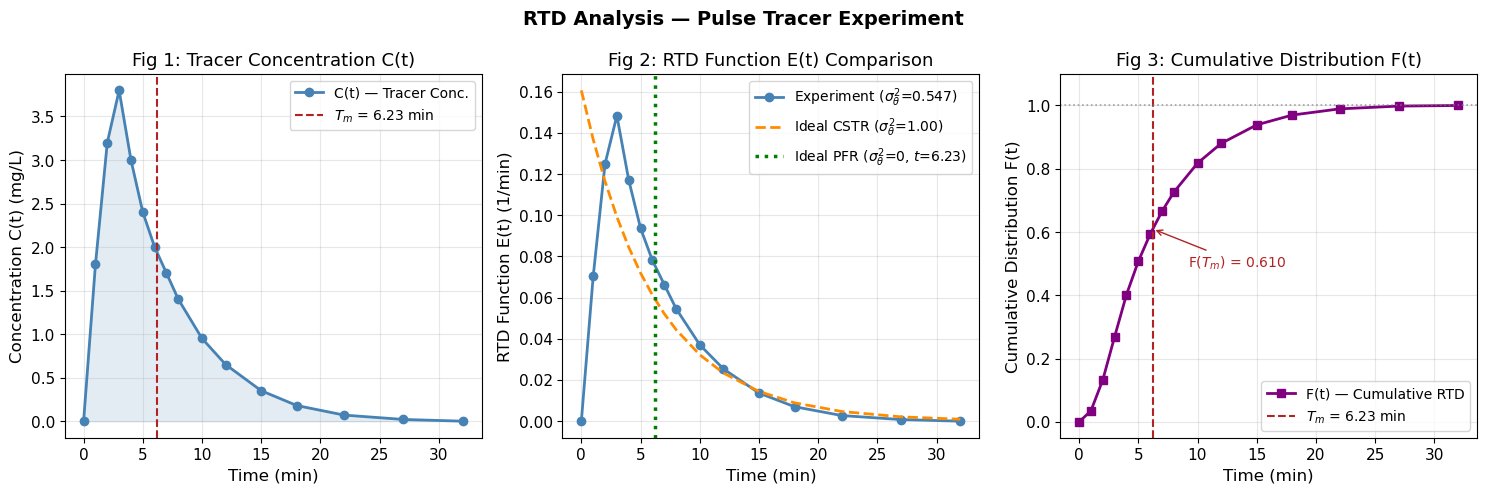

In [7]:
# ========================================
# 圖形繪製：Fig 1–3
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("RTD Analysis — Pulse Tracer Experiment", fontsize=14, fontweight='bold')

# ---------------------------------------
# Fig 1: C(t) 原始濃度響應曲線
# ---------------------------------------
ax1 = axes[0]
ax1.plot(t, C, 'o-', color='steelblue', linewidth=2, markersize=6, label='C(t) — Tracer Conc.')
ax1.axvline(T_m, color='firebrick', linestyle='--', linewidth=1.5, label=f'$T_m$ = {T_m:.2f} min')
ax1.fill_between(t, C, alpha=0.15, color='steelblue')
ax1.set_xlabel('Time (min)')
ax1.set_ylabel('Concentration C(t) (mg/L)')
ax1.set_title('Fig 1: Tracer Concentration C(t)')
ax1.legend()

# ---------------------------------------
# Fig 2: E(t) 與理想模型比較
# ---------------------------------------
ax2 = axes[1]
# 實驗 E(t)
ax2.plot(t, E, 'o-', color='steelblue', linewidth=2, markersize=6, label=f'Experiment ($\\sigma_\\theta^2$={sigma_theta2:.3f})')
# 理想 CSTR
ax2.plot(t, E_CSTR, '--', color='darkorange', linewidth=2,
         label=f'Ideal CSTR ($\\sigma_\\theta^2$=1.00)')
# 理想 PFR：垂直線於 t = T_m
ax2.axvline(T_m, color='green', linestyle=':', linewidth=2.5,
            label=f'Ideal PFR ($\\sigma_\\theta^2$=0, $t$={T_m:.2f})')
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('RTD Function E(t) (1/min)')
ax2.set_title('Fig 2: RTD Function E(t) Comparison')
ax2.legend()

# ---------------------------------------
# Fig 3: F(t) 累積分布函數
# ---------------------------------------
ax3 = axes[2]
ax3.plot(t, F, 's-', color='purple', linewidth=2, markersize=6, label='F(t) — Cumulative RTD')
ax3.axvline(T_m, color='firebrick', linestyle='--', linewidth=1.5, label=f'$T_m$ = {T_m:.2f} min')
ax3.axhline(1.0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
# 標注 F(T_m)
F_at_Tm = np.interp(T_m, t, F)
ax3.annotate(f'F($T_m$) = {F_at_Tm:.3f}',
             xy=(T_m, F_at_Tm), xytext=(T_m + 3, F_at_Tm - 0.12),
             arrowprops=dict(arrowstyle='->', color='firebrick'),
             fontsize=10, color='firebrick')
ax3.set_xlabel('Time (min)')
ax3.set_ylabel('Cumulative Distribution F(t)')
ax3.set_title('Fig 3: Cumulative Distribution F(t)')
ax3.set_ylim(-0.05, 1.10)
ax3.legend()

plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'Fig1_3_RTD_Analysis.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ 圖檔已儲存：{fig_path}")
plt.show()

---
### 7. 重點整理

#### 計算結果摘要

| 計算項目 | 符號 | 數值 | 單位 | 說明 |
|:---------|:----:|-----:|:----:|:-----|
| $C(t)$ 積分面積 | $\int C\,dt$ | ≈ 25.62 | mg·min/L | 正規化分母 |
| 平均滯留時間 | $T_m$ | ≈ 6.23 | min | 一次矩 |
| 方差 | $\sigma^2$ | ≈ 21.19 | min² | 二次中心矩 |
| 無因次方差 | $\sigma_\theta^2$ | ≈ 0.547 | — | 流動模式指標 |
| 累積分布終值 | $F(\infty)$ | ≈ 1.000 | — | 正規化驗證 |

#### 流動模式結論

本案例 $\sigma_\theta^2 \approx 0.547$ ，介於理想 PFR（ $\sigma_\theta^2 = 0$ ）與理想 CSTR（ $\sigma_\theta^2 = 1$ ）之間，反映**部分混合（Partial Mixing）**的流動特性，可能存在以下原因：
- 反應器內部存在軸向混合（Axial Dispersion）
- 攪拌強度不均勻，形成局部渦流
- 部分流體短路（Short-circuiting）

#### 關鍵 Python 技巧

| 操作 | Python 語法 | 說明 |
|:-----|:------------|:-----|
| 非等間距積分 | `scipy.integrate.trapezoid(y, x)` | 梯形法，自動處理非均勻步長 |
| E(t) 正規化 | `E = C / scipy.integrate.trapezoid(C, t)` | 直接向量除法 |
| 平均滯留時間 | `T_m = scipy.integrate.trapezoid(t * E, t)` | 一次矩公式 |
| 方差 | `sigma2 = scipy.integrate.trapezoid((t - T_m)**2 * E, t)` | 二次中心矩 |
| 累積分布 | `F[i] = scipy.integrate.trapezoid(E[:i+1], t[:i+1])` | 逐點梯形積分 |
